Import packages

In [83]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cobra
from cobra.io import read_sbml_model, write_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from tqdm import tqdm

In [2]:
from pathlib import Path
import plotly
import plotly.express as px
import scipy.stats

os.environ["OMP_NUM_THREADS"] = "1"  # because of a data leak of KMeans on windows
import fba_comparison_stats as cmp
from efflux_method import *
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

In [3]:
table = pd.read_csv("/home/mickael/github/M_xanthus-E_coli-Predation/data/Raw/WT_vs_4preys_RIPTiDe.csv")
table.set_index("GeneNames", inplace=True)

In [4]:
table.corr()

,Ec1,Ec2,Ec3,B1,B2,B3,C1,C2,C3,Y1,...,W3,K1,K2,K3,WC1,WC2,WC3,KC1,KC2,KC3
Ec1,1.000000,0.968995,0.937906,0.972749,0.969625,0.914176,0.914936,0.906303,0.913233,0.887547,...,0.782695,0.793274,0.796777,0.782234,0.708432,0.692272,0.779508,0.500804,0.663639,0.578153
Ec2,0.968995,1.000000,0.978197,0.934636,0.947817,0.843680,0.875137,0.925230,0.875138,0.884889,...,0.788704,0.768716,0.788043,0.752694,0.683772,0.703797,0.757646,0.520501,0.676548,0.568213
Ec3,0.937906,0.978197,1.000000,0.909243,0.919928,0.806393,0.824667,0.892809,0.819892,0.864344,...,0.804885,0.745334,0.770833,0.710687,0.696607,0.736337,0.750268,0.588954,0.718862,0.581460
B1,0.972749,0.934636,0.909243,1.000000,0.981634,0.949993,0.945318,0.909903,0.938607,0.910277,...,0.830779,0.836848,0.834620,0.832051,0.770295,0.741859,0.840801,0.532954,0.702349,0.632454
B2,0.969625,0.947817,0.919928,0.981634,1.000000,0.941838,0.951038,0.944823,0.944599,0.929618,...,0.854008,0.847019,0.854903,0.838708,0.764988,0.753275,0.848127,0.559171,0.714211,0.627261
B3,0.914176,0.843680,0.806393,0.949993,0.941838,1.000000,0.943827,0.859134,0.944039,0.889452,...,0.820639,0.862020,0.844586,0.869438,0.794877,0.724616,0.858050,0.516032,0.685758,0.648963
C1,0.914936,0.875137,0.824667,0.945318,0.951038,0.943827,1.000000,0.940390,0.991175,0.910023,...,0.823686,0.829719,0.819504,0.837021,0.743173,0.710790,0.829748,0.491007,0.634133,0.564708
C2,0.906303,0.925230,0.892809,0.909903,0.944823,0.859134,0.940390,1.000000,0.941037,0.918112,...,0.843909,0.810714,0.826431,0.804938,0.711571,0.736620,0.816491,0.551436,0.665972,0.555221
C3,0.913233,0.875138,0.819892,0.938607,0.944599,0.944039,0.991175,0.941037,1.000000,0.916218,...,0.822589,0.840579,0.831770,0.854536,0.745123,0.708024,0.838730,0.481439,0.633523,0.572699
Y1,0.887547,0.884889,0.864344,0.910277,0.929618,0.889452,0.910023,0.918112,0.916218,1.000000,...,0.909825,0.904696,0.909859,0.887583,0.818236,0.806952,0.900764,0.591179,0.763982,0.656763


Import the models

How to make each models, how to put information in it? Efflux?

In [5]:
M_xanthus = read_sbml_model("../M_xanthus_model_V4.xml")

In [ ]:
#Add importation constraints
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0

In [7]:
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3362,0,0.00%
ca2_e,EX_ca2_e,0.08405,0,0.00%
cl_e,EX_cl_e,0.08405,0,0.00%
cobalt2_e,EX_cobalt2_e,0.08405,0,0.00%
cu2_e,EX_cu2_e,0.08405,0,0.00%
h2s_e,EX_h2s_e,12.08,0,0.00%
hdca_e,EX_hdca_e,99.59,16,85.09%
ile_L_e,EX_ile_L_e,12.26,6,3.93%
k_e,EX_k_e,0.08405,0,0.00%
leu_L_e,EX_leu_L_e,19.03,6,6.10%


In [8]:
list_of_genes = []
for i in M_xanthus.genes:
    list_of_genes.append(i.id)

In [ ]:
# Getting fluxes with constrains
dico = {
    14: "Alone",
    2: "P_E_coli_1-3",
    5: "P_B_subtilis",
    8: "P_Caulobacter",
    20: "P_E_coli_1-1",
}
for i in [14, 2, 5, 8, 20]:
    M_xanthus = read_sbml_model("../M_xanthus_model_V4.xml")
    #Add importation constraints
    M_xanthus.reactions.EX_alaala_e.lower_bound = 0
    M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
    M_xanthus.reactions.EX_his_L_e.lower_bound = 0
    M_xanthus.reactions.EX_co2_e.lower_bound = 0
    M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
    M_xanthus.reactions.EX_malt_e.lower_bound = 0
    M_xanthus.reactions.EX_met_L_e.lower_bound = 0
    M_xanthus.reactions.EX_pheme_e.lower_bound = 0
    M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
    M_xanthus.reactions.EX_orn_e.lower_bound = 0
    M_xanthus.reactions.EX_ac_e.lower_bound = 0
    M_xanthus.reactions.EX_fru_e.lower_bound = 0
    M_xanthus.reactions.EX_for_e.lower_bound = 0
    DictAP = read_csv_data(
        "/home/mickael/github/M_xanthus-E_coli-Predation/data/Raw/WT_vs_4preys_iMAT.csv",
        id_gene=1,
        id_val=i,
        list_of_genes=list_of_genes,
        head=True,
        quantile=0.95,
    )
    Eflux(M_xanthus, DictAP, const=100, default_exp_val=1, ignore_human=True)
    M_xanthus.reactions.EX_glc_D_e.bounds = (0, 1000)
    model_c = M_xanthus.copy()
    write_sbml_model(
        model_c,
        "/home/mickael/github/M_xanthus-E_coli-Predation/fba_comparer-main/Models_Preda/M_xanthus_V4_efflux_"
        + dico[i]
        + ".xml",
    )
    print(dico[i] + " Done!")

Alone Done!
P_E_coli_1-3 Done!
P_B_subtilis Done!
P_Caulobacter Done!
P_E_coli_1-1 Done!


In [10]:
M_xanthus_alone = read_sbml_model("Models_Preda/M_xanthus_V4_efflux_Alone.xml")
solution_alone = M_xanthus_alone.optimize()

In [11]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-3.xml"
)
solution_predation_E_3 = M_xanthus_predation.optimize()

In [12]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_B_subtilis.xml"
)
solution_predation_B = M_xanthus_predation.optimize()

In [13]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_Caulobacter.xml"
)
solution_predation_C = M_xanthus_predation.optimize()

In [14]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-1.xml"
)
solution_predation_E_1 = M_xanthus_predation.optimize()

In [15]:
print(f"Alone:\t{solution_alone.objective_value}")
print(f"Predation E.coli 1/1 :\t{solution_predation_E_1.objective_value}")
print(f"Predation E.coli 1/3 :\t{solution_predation_E_3.objective_value}")
print(f"Predation B_subtilis:\t{solution_predation_B.objective_value}")
print(f"Predation Caulobacter:\t{solution_predation_C.objective_value}")

Alone:	0.20445275853613473
Predation E.coli 1/1 :	0.1675477871556389
Predation E.coli 1/3 :	0.10165517381424218
Predation B_subtilis:	0.15158979104534906
Predation Caulobacter:	0.1675252156829574


## **FBA Comparer**
**Create combined dataframe and preprocess data**

Filter all reactions where fluxes are zero:

In [16]:
solutions = [
    solution_alone,
    solution_predation_E_1,
    solution_predation_E_3,
    solution_predation_B,
    solution_predation_C,
]
conditions = [
    "Alone",
    "Predation E.coli 1/1",
    "Predation E.coli 1/3",
    "Predation B. subtilis",
    "Predation Caulobacter",
]
obj_values = [
    solution_alone.objective_value,
    solution_predation_E_1.objective_value,
    solution_predation_E_3.objective_value,
    solution_predation_B.objective_value,
    solution_predation_C.objective_value,
]

mxanthus = cmp.build_dataframe(M_xanthus_alone, solutions, conditions)
mxanthus_filtered = cmp.filter_dataframe(mxanthus, conditions, rounding=True)
print(f"Number of reactions in the models: {len(mxanthus)}")
print(f"Number of nonzero reactions in the models: {len(mxanthus_filtered)}")

Number of reactions in the models: 1339
Number of nonzero reactions in the models: 455


normalize data:

In [17]:
mxanthus_normalized = cmp.normalize_dataframe_cols(
    mxanthus_filtered, conditions, obj_values
)  # biomass normalization
mxanthus_normalized_div_by_max = cmp.normalize_dataframe_rows(
    mxanthus_normalized, conditions, "div_by_max"
)  # normalization reactions
# note: there is no difference between the order of div_by_max normalization and filtering for changing reactions
mxanthus_normalized_div_by_max_changing = mxanthus_normalized_div_by_max[
    mxanthus_normalized_div_by_max["Std_dev"] >= 0.01
]  # keep only reactions that change
print(
    f"Number of normalized changing reactions: {len(mxanthus_normalized_div_by_max_changing)}"
)

Number of normalized changing reactions: 154


## Identify reactions with most/least variation

Most affected / change reaction

In [18]:
most_variable_bar_plot = cmp.bar_plot_flux_variation(
    mxanthus_normalized, conditions, 0, 10
)
most_variable_bar_plot.show()

In [19]:
sorted_flux = mxanthus_normalized[["ID", "Name", "Std_dev"]].sort_values(
    by=["Std_dev"], ascending=False
)
sorted_flux["Kegg"] = [
    M_xanthus_alone.reactions.get_by_id(id).__dict__["_annotation"].get("kegg.reaction")
    for id in sorted_flux["ID"]
]
sorted_flux[0:20]

,ID,Name,Std_dev,Kegg
342,rxn01444_c,ATP:deoxyguanosine 5'-phosphotransferase [c],12.185052,R01967
217,rxn01445_c,2'-Deoxyguanosine 5'-monophosphate phosphohydr...,12.027347,R01968
842,rxn01507_c,2'-Deoxyadenosine 5'-monophosphate phosphohydr...,11.477667,R02088
583,rxn01508_c,ATP:deoxyadenosine 5'-phosphotransferase [c],11.477667,R02089
672,rxn05312_c,Inorganic phosphate transporter [c],3.421294,None
1261,EX_pi_e,Exchange for Phosphate [e],3.421294,None
1276,EX_h2o_e,Exchange for H2O [e],3.066962,None
158,rxn05319_c,TRANS-RXNBWI-115401.ce.maizeexp.OH_OH [c],3.066962,None
499,rxn00711_c,UMP:diphosphate phospho-alpha-D-ribosyltransfe...,2.063028,R00966
1289,EX_h_e,Exchange for H+ [e],1.955380,None


In [69]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Glycolysis / Gluconeogenesis":
        liste.append(i)

sorted_flux.loc[sorted_flux["ID"].isin(liste)]

,ID,Name,Std_dev,Kegg
298,rxn00747_c,D-glyceraldehyde-3-phosphate aldose-ketose-iso...,0.965364,R01015
531,rxn01106_c,"2-Phospho-D-glycerate 2,3-phosphomutase [c]",0.965364,R01518
700,rxn00459_c,2-phospho-D-glycerate hydro-lyase (phosphoenol...,0.965364,R00658
417,rxn01100_c,ATP:3-phospho-D-glycerate 1-phosphotransferase...,0.965364,R01512
157,rxn00781_c,D-glyceraldehyde-3-phosphate:NAD+ oxidoreducta...,0.965364,R01061
16,rxn02342_c,R03270 [c],0.407769,R03270
383,rxn01871_c,acetyl-CoA:enzyme N6-(dihydrolipoyl)lysine S-a...,0.407769,R02569
657,rxn00011_c,pyruvate:thiamin diphosphate acetaldehydetrans...,0.407769,R00014
216,rxn00305_c,GTP:oxaloacetate carboxy-lyase (adding GTP;pho...,0.395647,R00431


Pathway analysis

In [71]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(liste)]

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
16,rxn02342_c,rxn02342_c: 2_Hydroxyethyl_ThPP_c + lpam_c <=>...,R03270 [c],0.000000,-0.373371,-0.838664,-0.927684,-0.899519,0.407769,-0.607847
157,rxn00781_c,rxn00781_c: g3p_c + nad_c + pi_c <=> 13dpg_c +...,D-glyceraldehyde-3-phosphate:NAD+ oxidoreducta...,3.180421,2.061616,1.220050,1.144417,0.767557,0.965364,1.674812
216,rxn00305_c,rxn00305_c: gtp_c + oaa_c <=> co2_c + gdp_c + ...,GTP:oxaloacetate carboxy-lyase (adding GTP;pho...,-1.791100,-1.079034,-0.702760,-1.078740,-1.078740,0.395647,-1.146075
298,rxn00747_c,rxn00747_c: g3p_c <=> dhap_c,D-glyceraldehyde-3-phosphate aldose-ketose-iso...,-3.558462,-2.439657,-1.598090,-1.522458,-1.145598,0.965364,-2.052853
383,rxn01871_c,rxn01871_c: accoa_c + dhlam_c <=> adhlam_c + c...,acetyl-CoA:enzyme N6-(dihydrolipoyl)lysine S-a...,0.000000,0.373371,0.838664,0.927684,0.899519,0.407769,0.607847
417,rxn01100_c,rxn01100_c: 3pg_c + atp_c <=> 13dpg_c + adp_c,ATP:3-phospho-D-glycerate 1-phosphotransferase...,-3.180421,-2.061616,-1.220050,-1.144417,-0.767557,0.965364,-1.674812
531,rxn01106_c,rxn01106_c: 2pg_c <=> 3pg_c,"2-Phospho-D-glycerate 2,3-phosphomutase [c]",-3.180421,-2.061616,-1.220050,-1.144417,-0.767557,0.965364,-1.674812
657,rxn00011_c,rxn00011_c: 2_Hydroxyethyl_ThPP_c + co2_c <=> ...,pyruvate:thiamin diphosphate acetaldehydetrans...,0.000000,0.373371,0.838664,0.927684,0.899519,0.407769,0.607847
700,rxn00459_c,rxn00459_c: 2pg_c <=> h2o_c + pep_c,2-phospho-D-glycerate hydro-lyase (phosphoenol...,3.180421,2.061616,1.220050,1.144417,0.767557,0.965364,1.674812


In [93]:
M_xanthus.metabolites.gam_e.summary()

Percent,Flux,Reaction,Definition
100.00%,0.1411,EX_gam_e,gam_e <=>
Percent,Flux,Reaction,Definition
100.00%,-0.1411,rxn05569_c,gam_e + pep_c --> gam6p_c + pyr_c


In [81]:
M_xanthus.metabolites.dgtp_c.summary()

Percent,Flux,Reaction,Definition
100.00%,0.1351,rxn01510_c,cytd_c + dgtp_c <=> cmp_c + dgdp_c + h_c
Percent,Flux,Reaction,Definition
0.78%,-0.001053,OF_DNA,0.516637656497864 datp_c + 0.516637656497864 dctp_c + 0.516637656497864 dgtp_c + 0.516637656497864 dttp_c --> Biomass_c + dna_c + 2.06655062599146 ppi_c
99.22%,-0.134,rxn01354_c,dgtp_c + pyr_c <=> dgdp_c + h_c + pep_c


In [20]:
from bioservices import KEGG

k = KEGG()

for rxn in M_xanthus.reactions:
    if "kegg.reaction" in rxn.annotation:
        kegg_id = rxn.annotation["kegg.reaction"]
        try:
            data = k.get(kegg_id)
            parsed = k.parse(data)
            if "PATHWAY" in parsed:
                rxn.subsystem = list(parsed["PATHWAY"].values())[0]
        except:
            continue

WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02371)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R01549)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02097)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02292)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00962)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00967)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https

In [21]:
pathway_dict_M = {}
for i in M_xanthus.reactions:
    if i.subsystem in pathway_dict_M:
        pathway_dict_M[i.subsystem].append(i.id)
    else:
        pathway_dict_M[i.subsystem] = [i.id]

In [22]:
pw_list = cmp.pathway_variability(
    mxanthus_normalized, pathway_dict_M, ascending=True, num=20
)

Purine metabolism		 -> 1.60 (contains 37 reactions)
Glycolysis / Gluconeogenesis		 -> 0.72 (contains 9 reactions)
Glycerophospholipid metabolism		 -> 0.62 (contains 2 reactions)
Glycerolipid metabolism		 -> 0.46 (contains 3 reactions)
Pyrimidine metabolism		 -> 0.39 (contains 27 reactions)
Citrate cycle (TCA cycle)		 -> 0.32 (contains 8 reactions)
Valine, leucine and isoleucine degradation		 -> 0.31 (contains 17 reactions)
Alanine, aspartate and glutamate metabolism		 -> 0.27 (contains 6 reactions)
		 -> 0.24 (contains 147 reactions)
Glyoxylate and dicarboxylate metabolism		 -> 0.16 (contains 3 reactions)
Glycine, serine and threonine metabolism		 -> 0.08 (contains 12 reactions)
Carbapenem biosynthesis		 -> 0.07 (contains 1 reactions)
Cysteine and methionine metabolism		 -> 0.06 (contains 6 reactions)
Arginine biosynthesis		 -> 0.05 (contains 11 reactions)
Fatty acid degradation		 -> 0.05 (contains 5 reactions)
Lysine degradation		 -> 0.04 (contains 1 reactions)
Thiamine metabolism		 -

In [51]:
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Glycolysis / Gluconeogenesis":
        print(i)

rxn02342_c
rxn00172_c
rxn00545_c
rxn00148_c
rxn00781_c
rxn00549_c
rxn00506_c
rxn00305_c
rxn00747_c
rxn00147_c
rxn01871_c
rxn00786_c
rxn01100_c
rxn01106_c
rxn00543_c
rxn00011_c
rxn00459_c
rxn00175_c
rxn01171_c
rxn15249_c
rxn20583_c


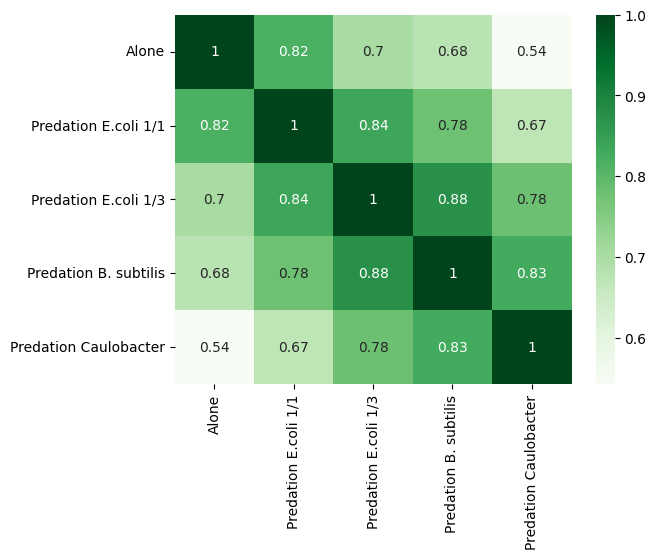

In [24]:
fig_r = cmp.correlation_matrix(
    mxanthus_normalized_div_by_max_changing, conditions, color="Greens"
)

## Flux correlation network

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
corr_matrix = cmp.flux_coupling_matrix(
    mxanthus_normalized_div_by_max, conditions, remove_unchanging=0.01, abs_values=True
)

301 reaction were removed, because their Std_dev is lower than 0.01
The following 2 reactions were removed because they swap signs across conditions: ['rxn00416_c', 'rxn00991_c']


In [27]:
mask = []
for i in corr_matrix:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Purine metabolism":
        mask.append(i)

new = corr_matrix.filter(mask, axis=0)
corr_matrix_filter = new.filter(mask, axis=1)

corr_matrix_filter

,rxn00836_c,rxn01358_c,rxn00800_c,rxn00097_c,rxn00913_c,rxn01445_c,rxn00917_c,rxn01444_c,rxn00237_c,rxn00132_c,...,rxn00831_c,rxn01509_c,rxn01548_c,rxn01544_c,rxn01508_c,rxn01507_c,rxn01446_c,rxn05233_c,rxn01225_c,rxn01137_c
rxn00836_c,1.000000,1.000000,0.810795,0.326324,-0.214075,-0.497699,0.637720,-0.514033,0.730304,0.812068,...,-0.907105,-0.907105,-0.214075,0.637720,0.247758,0.247758,-0.907105,-0.907105,0.637720,0.810795
rxn01358_c,1.000000,1.000000,0.810795,0.326324,-0.214075,-0.497699,0.637720,-0.514033,0.730304,0.812068,...,-0.907105,-0.907105,-0.214075,0.637720,0.247758,0.247758,-0.907105,-0.907105,0.637720,0.810795
rxn00800_c,0.810795,0.810795,1.000000,0.641858,-0.453723,-0.327495,0.158414,-0.335537,0.979861,0.999997,...,-0.489109,-0.489109,-0.453723,0.158414,-0.001723,-0.001723,-0.489109,-0.489109,0.158414,1.000000
rxn00097_c,0.326324,0.326324,0.641858,1.000000,-0.951320,-0.619536,-0.500912,-0.612138,0.769829,0.640644,...,-0.024715,-0.024715,-0.951320,-0.500912,0.363285,0.363285,-0.024715,-0.024715,-0.500912,0.641858
rxn00913_c,-0.214075,-0.214075,-0.453723,-0.951320,1.000000,0.761452,0.554217,0.751415,-0.612534,-0.452622,...,-0.007265,-0.007265,1.000000,0.554217,-0.597716,-0.597716,-0.007265,-0.007265,0.554217,-0.453723
rxn01445_c,-0.497699,-0.497699,-0.327495,-0.619536,0.761452,1.000000,-0.003906,0.999766,-0.420532,-0.327912,...,0.506143,0.506143,0.761452,-0.003906,-0.927583,-0.927583,0.506143,0.506143,-0.003906,-0.327495
rxn00917_c,0.637720,0.637720,0.158414,-0.500912,0.554217,-0.003906,1.000000,-0.024855,-0.016427,0.160598,...,-0.836377,-0.836377,0.554217,1.000000,-0.019304,-0.019304,-0.836377,-0.836377,1.000000,0.158414
rxn01444_c,-0.514033,-0.514033,-0.335537,-0.612138,0.751415,0.999766,-0.024855,1.000000,-0.424722,-0.335996,...,0.524700,0.524700,0.751415,-0.024855,-0.924879,-0.924879,0.524700,0.524700,-0.024855,-0.335537
rxn00237_c,0.730304,0.730304,0.979861,0.769829,-0.612534,-0.420532,-0.016427,-0.424722,1.000000,0.979534,...,-0.383647,-0.383647,-0.612534,-0.016427,0.099874,0.099874,-0.383647,-0.383647,-0.016427,0.979861
rxn00132_c,0.812068,0.812068,0.999997,0.640644,-0.452622,-0.327912,0.160598,-0.335996,0.979534,1.000000,...,-0.491008,-0.491008,-0.452622,0.160598,-0.001151,-0.001151,-0.491008,-0.491008,0.160598,0.999997


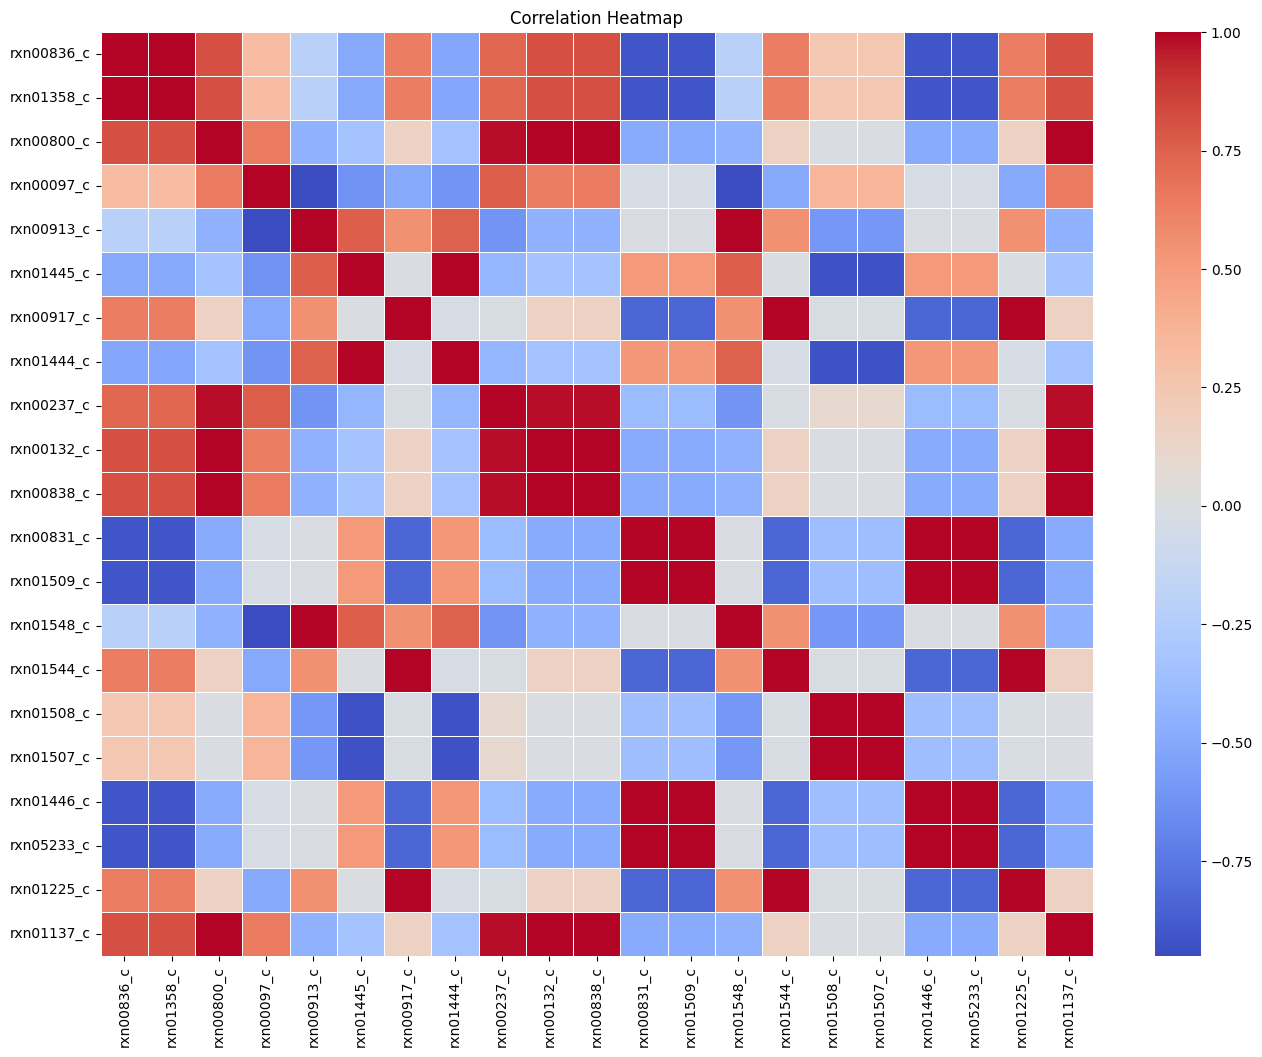

In [28]:
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix_filter, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [29]:
# Correlation network
nw = cmp.flux_coupling_network(corr_matrix, pc=0.7)
fig = cmp.visualize_interactive_network(nw, mxanthus_normalized_div_by_max, conditions)
fig.show()

Created Flux Coupling network with pc threshold 0.7.
Number of nodes: 152
Number of edges: 2157
Number of connected components: 2


In [30]:
# # Colored pathway network
# nw3 = nw
# cmp.color_network_by_pathway(
#     nw3, pathway= "Purine metabolism", pathway_dict= pathway_dict_M
# )  # takes edge weights into account!

# fig = cmp.visualize_interactive_network(nw3, mxanthus_normalized_div_by_max, conditions)
# fig.show()

In [31]:
# Colored community network
nw2 = nw
cmp.color_network_by_communities(
    nw2, 8, include_weights=True
)  # takes edge weights into account!

comm_map = cmp.get_community_list(nw)
color = cmp.get_color_map(comm_map)

fig = cmp.visualize_interactive_network(nw2, mxanthus_normalized_div_by_max, conditions)
fig.show()

Community map

In [39]:
fig = cmp.community_bar_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()

In [40]:
fig = cmp.community_box_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()

In [41]:
with open("pathway_information/mxanthus_filtered_ids.tsv", "w") as file:
    for line in M_xanthus.reactions:
        file.write(line.id + "\n")

In [ ]:
## load ID dictionary (mapping ids to pathways)
filtered_ids = []
with open("pathway_information/mxanthus_filtered_ids.tsv", "r") as file:
    for line in file:
        filtered_ids.append(line.strip())
id_dict = {}
with open("pathway_information/ecoli_map_id_to_pathway.tsv", "r") as file: #TODO REDO THIS FILE FOR MYXO / line correspond to mxanthus_filtered_ids
    for id, line in zip(filtered_ids, file):
        if line == "\n":
            continue
        words = line.strip().split("\t")
        id_dict[id] = words

pathway_hierarchy = {}
with open("pathway_information/kegg_pathway_hierarchy.txt", "r") as file:
    for line in file:
        line = line.rstrip("\n")
        words = line.replace("_", " ").split("\\t")
        pathway_hierarchy[words.pop(0)] = words

In [85]:
# sankey diagram of KEGG pathway categories
fig = cmp.community_sankey_diagram(
    comm_map,
    list(pathway_hierarchy.keys()),
    mxanthus_normalized_div_by_max,
    id_dict,
    diagram_height=1000,
    pw_hierarchy=pathway_hierarchy,
    text_size=16,
)
fig.show()

Look for community 1, 2 and 3

Try also for 7 and 10

In [32]:
for i in comm_map:
    print(i)

#FD3216
#00FE35
#6A76FC
#FED4C4
#FE00CE
#0DF9FF
#F6F926
#FF9616
#479B55
#EEA6FB


In [45]:
# Community 1
Genes_list_1 = []
for i in comm_map["#FD3216"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_1:
            Genes_list_1.append(str(j))

with open('Genes_list_1.txt', 'w') as f:
    for line in Genes_list_1:
        f.write(f"{line}\n")

In [46]:
# Community 2
Genes_list_2 = []
for i in comm_map["#00FE35"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_2:
            Genes_list_2.append(str(j))

with open('Genes_list_2.txt', 'w') as f:
    for line in Genes_list_2:
        f.write(f"{line}\n")

In [47]:
# Community 3
Genes_list_3 = []
for i in comm_map["#6A76FC"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_3:
            Genes_list_3.append(str(j))

with open('Genes_list_3.txt', 'w') as f:
    for line in Genes_list_3:
        f.write(f"{line}\n")

In [48]:
# Community 4
Genes_list_4 = []
for i in comm_map["#FED4C4"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_4:
            Genes_list_4.append(str(j))

with open('Genes_list_4.txt', 'w') as f:
    for line in Genes_list_4:
        f.write(f"{line}\n")

In [49]:
# Community 5
Genes_list_5 = []
for i in comm_map["#FE00CE"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_5:
            Genes_list_5.append(str(j))

with open('Genes_list_5.txt', 'w') as f:
    for line in Genes_list_5:
        f.write(f"{line}\n")

In [50]:
# Community 7
Genes_list_7 = []
for i in comm_map["#F6F926"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_7:
            Genes_list_7.append(str(j))

with open('Genes_list_7.txt', 'w') as f:
    for line in Genes_list_7:
        f.write(f"{line}\n")